# Le Défi du Détective de Données
## Analyse et nettoyage du jeu de données Cafe Sales

**Projet :** Semaine 1 – Data Analyst Challenge - Likabo  
**Outil :** Python / Pandas  
**Dataset :** Cafe Sales - Dirty Data for Cleaning Training

---

### Objectif

L'objectif de cette analyse est de prendre en main un jeu de données
transactionnel non documenté, d'en évaluer la qualité, d'identifier
les anomalies, de le nettoyer de manière justifiée puis d'en extraire
des insights utiles à la décision.

La démarche suivie est :

**Comprendre → Auditer → Nettoyer → Explorer → Interpréter → Vérifier**

## 1. Chargement des données

Je commence par charger le fichier brut sans effectuer aucune modification.

Une copie du jeu de données original sera conservée afin de pouvoir
comparer l'état des données avant et après nettoyage.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# fichier original
df_raw = pd.read_csv("dirty_cafe_sales.csv")

# Copie de travail
df = df_raw.copy()

print("Données chargées avec succès.")

Données chargées avec succès.


## 2. Compréhension initiale du jeu de données

Avant de nettoyer les données, il est nécessaire de comprendre leur
structure et d'identifier ce que représente chaque observation.

Je cherche notamment à répondre aux questions suivantes :

- Combien de transactions sont présentes ?
- Combien de variables ?
- Quels sont les noms des variables ?
- Quels types de données ont été détectés ?
- Existe-t-il déjà des anomalies visibles ?

In [4]:
print("Dimensions du dataset :", df.shape)
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])
df.columns.tolist()
df.head()

Dimensions du dataset : (10000, 8)
Nombre de lignes : 10000
Nombre de colonnes : 8


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


### Description initiale des variables

| Variable | Signification supposée |
|---|---|
| Transaction ID | Identifiant unique de la transaction |
| Item | Produit acheté |
| Quantity | Quantité achetée |
| Price Per Unit | Prix unitaire du produit |
| Total Spent | Montant total de la transaction |
| Payment Method | Moyen de paiement utilisé |
| Location | Type de lieu/service de la commande |
| Transaction Date | Date de la transaction |

Cette interprétation sera vérifiée au cours de l'analyse.

In [7]:
df.info()
df.dtypes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


Transaction ID      object
Item                object
Quantity            object
Price Per Unit      object
Total Spent         object
Payment Method      object
Location            object
Transaction Date    object
dtype: object

In [8]:
df.describe(include="all").T

,count,unique,top,freq
Transaction ID,10000,10000,TXN_1961373,1
Item,9667,10,Juice,1171
Quantity,9862,7,5,2013
Price Per Unit,9821,8,3.0,2429
Total Spent,9827,19,6.0,979
Payment Method,7421,5,Digital Wallet,2291
Location,6735,4,Takeaway,3022
Transaction Date,9841,367,UNKNOWN,159


## 3. Audit de la qualité des données

### 3.1 Valeurs manquantes

La première étape consiste à identifier les valeurs réellement absentes.

Cependant, une attention particulière est nécessaire : dans ce dataset,
certaines données manquantes ou invalides sont représentées sous forme
de chaînes de caractères comme `ERROR` ou `UNKNOWN`. Elles ne seront
donc pas détectées par `isna()`.

Je réalise d'abord un audit des valeurs manquantes natives.

In [9]:
missing = df.isna().sum()

missing_percentage = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "Valeurs manquantes": missing,
    "Pourcentage (%)": missing_percentage
})

missing_report.sort_values(
    by="Valeurs manquantes",
    ascending=False
)

,Valeurs manquantes,Pourcentage (%)
Location,3265,32.65
Payment Method,2579,25.79
Item,333,3.33
Price Per Unit,179,1.79
Total Spent,173,1.73
Transaction Date,159,1.59
Quantity,138,1.38
Transaction ID,0,0.00


### 3.2 Valeurs codant des anomalies

Les valeurs `ERROR` et `UNKNOWN` ne sont pas des valeurs manquantes
natives pour Pandas, mais elles représentent des informations
inexploitables ou inconnues.

Je les recherche donc explicitement dans chaque variable.

In [10]:
error_unknown_report = pd.DataFrame({
    "ERROR": (df == "ERROR").sum(),
    "UNKNOWN": (df == "UNKNOWN").sum()
})

error_unknown_report

,ERROR,UNKNOWN
Transaction ID,0,0
Item,292,344
Quantity,170,171
Price Per Unit,190,164
Total Spent,164,165
Payment Method,306,293
Location,358,338
Transaction Date,142,159


In [11]:
error_unknown_report["Total anomalies"] = (
    error_unknown_report["ERROR"] +
    error_unknown_report["UNKNOWN"]
)

error_unknown_report.sort_values(
    "Total anomalies",
    ascending=False
)

,ERROR,UNKNOWN,Total anomalies
Location,358,338,696
Item,292,344,636
Payment Method,306,293,599
Price Per Unit,190,164,354
Quantity,170,171,341
Total Spent,164,165,329
Transaction Date,142,159,301
Transaction ID,0,0,0


### 3.3 Analyse des modalités

Pour les variables catégorielles, j'examine les valeurs présentes afin
de détecter les modalités inattendues ou incohérentes.

In [12]:
categorical_columns = [
    "Item",
    "Payment Method",
    "Location"
]

for col in categorical_columns:
    print(f"\n===== {col} =====")
    print(df[col].value_counts(dropna=False))


===== Item =====
Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
NaN          333
ERROR        292
Name: count, dtype: int64

===== Payment Method =====
Payment Method
NaN               2579
Digital Wallet    2291
Credit Card       2273
Cash              2258
ERROR              306
UNKNOWN            293
Name: count, dtype: int64

===== Location =====
Location
NaN         3265
Takeaway    3022
In-store    3017
ERROR        358
UNKNOWN      338
Name: count, dtype: int64


### 3.4 Recherche de doublons

Une transaction dupliquée pourrait fausser les indicateurs de ventes.
Je vérifie donc à la fois les doublons sur l'ensemble des colonnes
et les doublons potentiels sur l'identifiant de transaction.

In [15]:
print("Doublons complets :", df.duplicated().sum())

print(
    "Transaction IDs dupliqués :",
    df["Transaction ID"].duplicated().sum()
)

Doublons complets : 0
Transaction IDs dupliqués : 0


In [18]:
numeric_columns = [
    "Quantity",
    "Price Per Unit",
    "Total Spent"
]

#conversion en type numerique
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce") 

df[numeric_columns].describe()

,Quantity,Price Per Unit,Total Spent
count,9521.000000,9467.000000,9498.000000
mean,3.028463,2.949984,8.924352
std,1.419007,1.278450,6.009919
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,4.000000
50%,3.000000,3.000000,8.000000
75%,4.000000,4.000000,12.000000
max,5.000000,5.000000,25.000000


### 3.5 Recherche de valeurs impossibles

Pour les variables quantitatives, je recherche les valeurs qui seraient
incompatibles avec la logique métier d'une transaction :

- quantité négative ;
- prix unitaire négatif ;
- montant total négatif.

Je vérifie également les dates situées dans le futur.

In [21]:
print("Quantités négatives :", (df["Quantity"] < 0).sum())
print("Prix unitaires négatifs :", (df["Price Per Unit"] < 0).sum())
print("Montants négatifs :", (df["Total Spent"] < 0).sum())

df["Transaction Date"] = pd.to_datetime(
    df["Transaction Date"],
    errors="coerce"
)

print("Dates invalides :", df["Transaction Date"].isna().sum())
print("Date minimale :", df["Transaction Date"].min())
print("Date maximale :", df["Transaction Date"].max())

Quantités négatives : 0
Prix unitaires négatifs : 0
Montants négatifs : 0
Dates invalides : 460
Date minimale : 2023-01-01 00:00:00
Date maximale : 2023-12-31 00:00:00


vérifions une règle métier fondamentale :

Total Spent=Quantity×Price Per Unit

In [22]:
valid_transactions = df[
    df["Quantity"].notna() &
    df["Price Per Unit"].notna() &
    df["Total Spent"].notna()
].copy()

valid_transactions["Expected Total"] = (
    valid_transactions["Quantity"] *
    valid_transactions["Price Per Unit"]
)

inconsistent = valid_transactions[
    ~np.isclose(
        valid_transactions["Total Spent"],
        valid_transactions["Expected Total"]
    )
]

print(
    "Transactions avec incohérence Quantity × Price ≠ Total :",
    len(inconsistent)
)

Transactions avec incohérence Quantity × Price ≠ Total : 0


In [23]:
# Vérification de l'unicité de l'identifiant
print("Nombre de transactions :", len(df))
print("Nombre d'IDs uniques :", df["Transaction ID"].nunique())
print("Nombre d'IDs dupliqués :", df["Transaction ID"].duplicated().sum())

Nombre de transactions : 10000
Nombre d'IDs uniques : 10000
Nombre d'IDs dupliqués : 0


L'identifiant `Transaction ID` est complet et unique pour les 10 000
observations. Il peut donc être utilisé comme clé d'identification
des transactions et ne présente pas d'anomalie d'unicité.

In [24]:
# Nombre de valeurs réellement absentes
missing = df.isna().sum()

# Nombre de valeurs codées ERROR et UNKNOWN
error = (df == "ERROR").sum()
unknown = (df == "UNKNOWN").sum()

# Total des valeurs non exploitables
quality_report = pd.DataFrame({
    "NaN": missing,
    "ERROR": error,
    "UNKNOWN": unknown
})

quality_report["Total non exploitable"] = (
    quality_report["NaN"]
    + quality_report["ERROR"]
    + quality_report["UNKNOWN"]
)

quality_report["% non exploitable"] = (
    quality_report["Total non exploitable"] / len(df) * 100
).round(2)

quality_report.sort_values(
    "Total non exploitable",
    ascending=False
)

,NaN,ERROR,UNKNOWN,Total non exploitable,% non exploitable
Location,3265,358,338,3961,39.61
Payment Method,2579,306,293,3178,31.78
Item,333,292,344,969,9.69
Price Per Unit,533,0,0,533,5.33
Total Spent,502,0,0,502,5.02
Quantity,479,0,0,479,4.79
Transaction Date,460,0,0,460,4.60
Transaction ID,0,0,0,0,0.00


# 4. Nettoyage des données

Le nettoyage est effectué sur une copie du jeu de données original.
Le fichier brut est conservé afin de garantir la traçabilité des
transformations et de permettre une comparaison avant/après.

In [28]:
df_clean = df_raw.copy()

## 4.1 Standardisation des valeurs invalides

L'audit a montré que certaines informations indisponibles sont représentées
de trois manières différentes :

- par une cellule vide (`NaN`) ;
- par la valeur `ERROR` ;
- par la valeur `UNKNOWN`.

Pour faciliter les traitements ultérieurs, les valeurs `ERROR` et `UNKNOWN`
seront converties en `NaN`.

Cette opération ne consiste pas à supprimer les données. Elle permet
simplement d'utiliser une représentation commune pour les informations
non disponibles ou non exploitables.

In [41]:
df_clean = df_clean.replace(
    ["ERROR", "UNKNOWN"],
    np.nan
) 
df_clean.isna().sum()

Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

## 4.2 Conversion des types de données

Après la standardisation des valeurs invalides, les variables quantitatives
peuvent être converties en types numériques.

Les colonnes `Quantity`, `Price Per Unit` et `Total Spent` doivent être
numériques afin de permettre les calculs statistiques et les contrôles
de cohérence.

La colonne `Transaction Date` doit quant à elle être convertie en format
date afin de permettre l'analyse temporelle. Les dates invalides
sont transformées en `NaT`, l'équivalent de `NaN` pour les dates.

In [42]:
numeric_columns = [
    "Quantity",
    "Price Per Unit",
    "Total Spent"
]

for col in numeric_columns:
    df_clean[col] = pd.to_numeric(
        df_clean[col],
        errors="coerce"
    ) 

df_clean["Transaction Date"] = pd.to_datetime(
    df_clean["Transaction Date"],
    errors="coerce"
)

df_clean.dtypes

Transaction ID              object
Item                        object
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
dtype: object

## 4.3 Contrôle de cohérence des transactions

Les variables `Quantity`, `Price Per Unit` et `Total Spent` sont liées
par une règle métier attendue :

    Total Spent = Quantity × Price Per Unit

Nous allons vérifier cette relation pour les transactions pour lesquelles
les trois informations sont disponibles.

Cette vérification permet de déterminer si les montants enregistrés sont
cohérents avec les quantités et les prix unitaires.

In [45]:
mask_complete = (
    df_clean["Quantity"].notna()
    & df_clean["Price Per Unit"].notna()
    & df_clean["Total Spent"].notna()
)

df_check = df_clean[mask_complete].copy()

df_check["Total Expected"] = (
    df_check["Quantity"]
    * df_check["Price Per Unit"]
)

df_check["Difference"] = (
    df_check["Total Spent"]
    - df_check["Total Expected"]
)

inconsistent = df_check[
    ~np.isclose(df_check["Difference"], 0)
]

print(
    "Transactions incohérentes :",
    len(inconsistent)
)

Transactions incohérentes : 0


### Interprétation

Aucune incohérence n'a été détectée parmi les transactions pour lesquelles
la quantité, le prix unitaire et le montant total sont simultanément
disponibles.

La relation `Total Spent = Quantity × Price Per Unit` semble donc cohérente
dans les observations exploitables.

Les problèmes observés sur ces variables semblent principalement provenir
de valeurs manquantes ou invalides plutôt que d'une erreur systématique
dans le calcul du montant total.

## 4.4 Recherche des valeurs pouvant être reconstruites

Certaines valeurs manquantes peuvent être récupérées sans inventer
d'information, grâce à la relation entre `Quantity`, `Price Per Unit`
et `Total Spent`.

Nous allons d'abord examiner les différents profils de valeurs manquantes.

In [46]:
numeric_missing_pattern = df_clean[
    ["Quantity", "Price Per Unit", "Total Spent"]
].isna().value_counts()

numeric_missing_pattern

Quantity  Price Per Unit  Total Spent
False     False           False          8544
          True            False           495
          False           True            462
True      False           False           441
False     True            True             20
True      False           True             20
          True            False            18
Name: count, dtype: int64

## 4.5 Reconstruction de `Total Spent`

Lorsque `Total Spent` est manquant mais que `Quantity` et `Price Per Unit`
sont disponibles, sa valeur peut être calculée sans hypothèse supplémentaire.

La règle utilisée est :

`Total Spent = Quantity × Price Per Unit`

Seules les observations satisfaisant cette condition seront modifiées.

In [48]:
mask_total = (
    df_clean["Total Spent"].isna()
    & df_clean["Quantity"].notna()
    & df_clean["Price Per Unit"].notna()
)

print(
    "Nombre de Total Spent récupérables :",
    mask_total.sum()
)

Nombre de Total Spent récupérables : 462


Les valeurs identifiées comme récupérables sont maintenant recalculées
à partir de la quantité et du prix unitaire.

In [49]:
df_clean.loc[mask_total, "Total Spent"] = (
    df_clean.loc[mask_total, "Quantity"]
    * df_clean.loc[mask_total, "Price Per Unit"]
)


## 4.6 Reconstruction de `Quantity`

Nous appliquons la même logique lorsque `Quantity` est manquante mais que
`Price Per Unit` et `Total Spent` sont disponibles.

La quantité peut alors être calculée par :

`Quantity = Total Spent / Price Per Unit`

Cette reconstruction doit cependant être contrôlée, car une quantité de
produits vendus doit normalement être une valeur entière.

In [50]:
mask_quantity = (
    df_clean["Quantity"].isna()
    & df_clean["Price Per Unit"].notna()
    & df_clean["Total Spent"].notna()
)

print(
    "Nombre de Quantity récupérables :",
    mask_quantity.sum()
)

Nombre de Quantity récupérables : 441


Nous calculons maintenant les quantités manquantes uniquement lorsque
le calcul est possible à partir des deux autres variables.

In [53]:
df_clean.loc[mask_quantity, "Quantity"] = (
    df_clean.loc[mask_quantity, "Total Spent"]
    / df_clean.loc[mask_quantity, "Price Per Unit"]
)

quantity_reconstructed = df_clean.loc[
    mask_quantity,
    "Quantity"
]

print(
    "Quantités reconstruites non entières :",
    (~np.isclose(quantity_reconstructed % 1, 0)).sum()
)

Quantités reconstruites non entières : 0


## 4.7 Reconstruction de `Price Per Unit`

Lorsque le prix unitaire est manquant mais que la quantité et le montant
total sont disponibles, nous pouvons utiliser :

`Price Per Unit = Total Spent / Quantity`

Cette reconstruction est déterministe et ne nécessite pas d'estimation
statistique.

In [54]:
mask_price = (
    df_clean["Price Per Unit"].isna()
    & df_clean["Quantity"].notna()
    & df_clean["Total Spent"].notna()
)

print(
    "Nombre de Price Per Unit récupérables :",
    mask_price.sum()
) 

df_clean.loc[mask_price, "Price Per Unit"] = (
    df_clean.loc[mask_price, "Total Spent"]
    / df_clean.loc[mask_price, "Quantity"]
)

Nombre de Price Per Unit récupérables : 495


## 4.8 Contrôle de cohérence après reconstruction

Après avoir reconstruit certaines valeurs, nous devons vérifier que les
transactions complètes respectent toujours la relation :

`Total Spent = Quantity × Price Per Unit`

Ce contrôle permet de s'assurer que nos transformations n'ont pas créé
de nouvelles incohérences.

In [55]:
df_check = df_clean[
    df_clean["Quantity"].notna()
    & df_clean["Price Per Unit"].notna()
    & df_clean["Total Spent"].notna()
].copy()

df_check["Total Expected"] = (
    df_check["Quantity"]
    * df_check["Price Per Unit"]
)

df_check["Difference"] = (
    df_check["Total Spent"]
    - df_check["Total Expected"]
)

inconsistent = df_check[
    ~np.isclose(df_check["Difference"], 0)
]

print(
    "Transactions incohérentes après nettoyage :",
    len(inconsistent)
)

Transactions incohérentes après nettoyage : 0


## 4.9 État des données après nettoyage

Nous pouvons maintenant mesurer les valeurs qui restent manquantes après
les reconstructions.

Il est important de ne pas chercher à remplir systématiquement toutes les
cellules restantes : certaines informations, comme le mode de paiement,
le lieu ou la date, ne peuvent pas être déduites de manière fiable à
partir des autres variables.

In [56]:
remaining_missing = df_clean.isna().sum()

remaining_missing_percentage = (
    remaining_missing / len(df_clean) * 100
).round(2)

remaining_report = pd.DataFrame({
    "Valeurs manquantes restantes": remaining_missing,
    "Pourcentage (%)": remaining_missing_percentage
})

remaining_report.sort_values(
    "Valeurs manquantes restantes",
    ascending=False
)

,Valeurs manquantes restantes,Pourcentage (%)
Location,3961,39.61
Payment Method,3178,31.78
Item,969,9.69
Transaction Date,460,4.60
Total Spent,40,0.40
Quantity,38,0.38
Price Per Unit,38,0.38
Transaction ID,0,0.00


## Pourquoi ne pas imputer toutes les valeurs manquantes ?

Toutes les valeurs manquantes ne peuvent pas être reconstruites avec
suffisamment de certitude.

Par exemple, lorsqu'un `Payment Method` est manquant, les autres variables
ne permettent pas de déterminer si le client a payé en espèces, par carte
ou par portefeuille numérique.

De même, une `Location` ou une `Transaction Date` manquante ne peut pas
être déduite de façon fiable à partir des variables disponibles.

Dans ces situations, il est préférable de conserver la valeur manquante
plutôt que d'inventer une information.

Cette approche permet de limiter les biais introduits artificiellement
dans les analyses ultérieures.

## 4.10 Synthèse des décisions de nettoyage

Les décisions prises sont résumées ci-dessous.

In [57]:
cleaning_decisions = pd.DataFrame({
    "Variable": [
        "Transaction ID",
        "Item",
        "Quantity",
        "Price Per Unit",
        "Total Spent",
        "Payment Method",
        "Location",
        "Transaction Date"
    ],
    "Décision": [
        "Conserver",
        "Standardiser les valeurs invalides en NaN",
        "Reconstruire lorsque possible",
        "Reconstruire lorsque possible",
        "Reconstruire lorsque possible",
        "Standardiser en NaN, sans imputation",
        "Standardiser en NaN, sans imputation",
        "Standardiser en NaN, sans imputation"
    ]
})

cleaning_decisions

,Variable,Décision
0,Transaction ID,Conserver
1,Item,Standardiser les valeurs invalides en NaN
2,Quantity,Reconstruire lorsque possible
3,Price Per Unit,Reconstruire lorsque possible
4,Total Spent,Reconstruire lorsque possible
5,Payment Method,"Standardiser en NaN, sans imputation"
6,Location,"Standardiser en NaN, sans imputation"
7,Transaction Date,"Standardiser en NaN, sans imputation"


## 4.11 Comparaison avant / après nettoyage

Pour évaluer l'effet du nettoyage, nous comparons le nombre de valeurs
manquantes avant et après les transformations.

Cette comparaison permet notamment de mesurer l'effet des reconstructions
effectuées sur les variables quantitatives.

In [58]:
before = df_raw.isna().sum()
after = df_clean.isna().sum()

comparison = pd.DataFrame({
    "Avant nettoyage": before,
    "Après nettoyage": after
})

comparison["Valeurs récupérées"] = (
    comparison["Avant nettoyage"]
    - comparison["Après nettoyage"]
)

comparison

,Avant nettoyage,Après nettoyage,Valeurs récupérées
Transaction ID,0,0,0
Item,333,969,-636
Quantity,138,38,100
Price Per Unit,179,38,141
Total Spent,173,40,133
Payment Method,2579,3178,-599
Location,3265,3961,-696
Transaction Date,159,460,-301


## 4.12 Sauvegarde du jeu de données nettoyé

Le jeu de données nettoyé est sauvegardé dans un fichier distinct.

Le fichier brut reste inchangé et constitue notre référence originale.
Cette séparation garantit la traçabilité du processus de nettoyage.

In [60]:
df_clean.to_csv(
    "cafe_sales_cleaned.csv",
    index=False
)

# 5. Analyse exploratoire des données

Après le nettoyage et les contrôles de cohérence, nous pouvons commencer
à explorer le jeu de données afin de comprendre l'activité commerciale
qu'il représente.

L'objectif n'est pas simplement de produire des graphiques, mais de
chercher des relations et des tendances qui pourraient révéler des
informations non évidentes dans les données brutes.

Nous chercherons notamment à comprendre :

- les produits et leur contribution aux ventes ;
- l'évolution de l'activité dans le temps ;
- le comportement des transactions selon leur localisation ;
- les montants dépensés et les quantités achetées ;
- les éventuelles différences entre volume de transactions et chiffre
  d'affaires.

Les conclusions seront formulées uniquement après observation des données.

## 5.1 Vue d'ensemble du jeu de données nettoyé

Nous commençons par observer les principales statistiques descriptives
des variables quantitatives.

Cette étape permet de connaître l'ordre de grandeur des quantités,
des prix et des montants dépensés avant d'étudier leurs distributions.

In [63]:
df_clean[[
    "Quantity",
    "Price Per Unit",
    "Total Spent"
]].describe()

,Quantity,Price Per Unit,Total Spent
count,9962.000000,9962.000000,9960.000000
mean,3.025597,2.947902,8.930924
std,1.420181,1.279759,6.004475
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,4.000000
50%,3.000000,3.000000,8.000000
75%,4.000000,4.000000,12.000000
max,5.000000,5.000000,25.000000


In [65]:
df_clean.shape

(10000, 8)

In [66]:
df_clean.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


## 5.2 Répartition des transactions par produit

Nous examinons d'abord le nombre de transactions associées à chaque
produit.

Cette analyse permet d'identifier les produits les plus fréquemment
achetés. Les valeurs manquantes sont exclues car elles ne permettent
pas d'identifier le produit concerné.

In [67]:
item_counts = (
    df_clean["Item"]
    .value_counts()
)

item_counts

Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
Name: count, dtype: int64

### Visualisation du nombre de transactions par produit

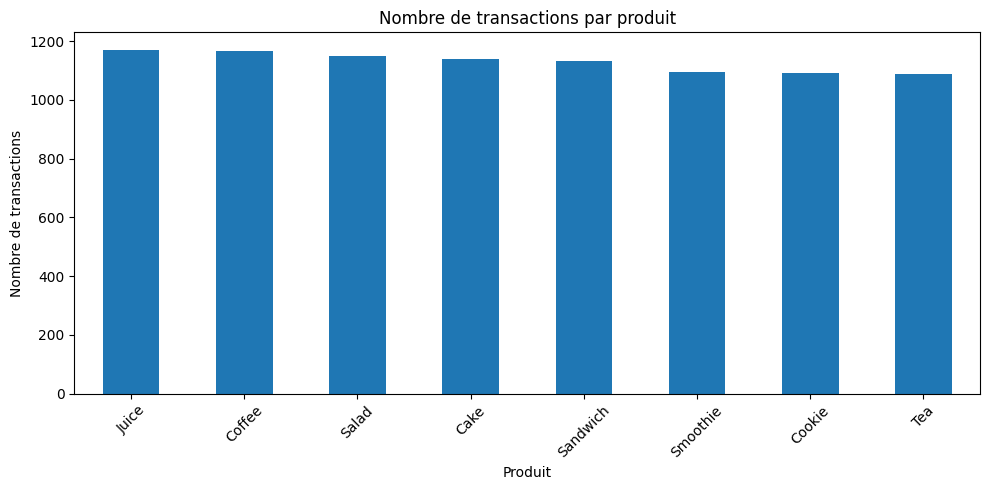

In [69]:
item_counts.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Nombre de transactions par produit")
plt.xlabel("Produit")
plt.ylabel("Nombre de transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5.3 Contribution de chaque produit au chiffre d'affaires

Le nombre de transactions ne permet pas à lui seul de mesurer la
performance commerciale d'un produit.

Un produit peut être acheté fréquemment tout en générant moins de
revenus qu'un produit moins fréquemment acheté mais vendu à un prix
plus élevé.

Nous calculons donc le chiffre d'affaires total associé à chaque produit.
Les transactions dont le produit ou le montant total est indisponible
ne peuvent pas être attribuées à un produit et sont exclues de ce calcul.

In [70]:
ca_by_item = (
    df_clean
    .dropna(subset=["Item", "Total Spent"])
    .groupby("Item")["Total Spent"]
    .sum()
    .sort_values(ascending=False)
)

ca_by_item

Item
Salad       17320.0
Sandwich    13664.0
Smoothie    13320.0
Juice       10509.0
Cake        10395.0
Coffee       7062.0
Tea          4951.5
Cookie       3223.0
Name: Total Spent, dtype: float64

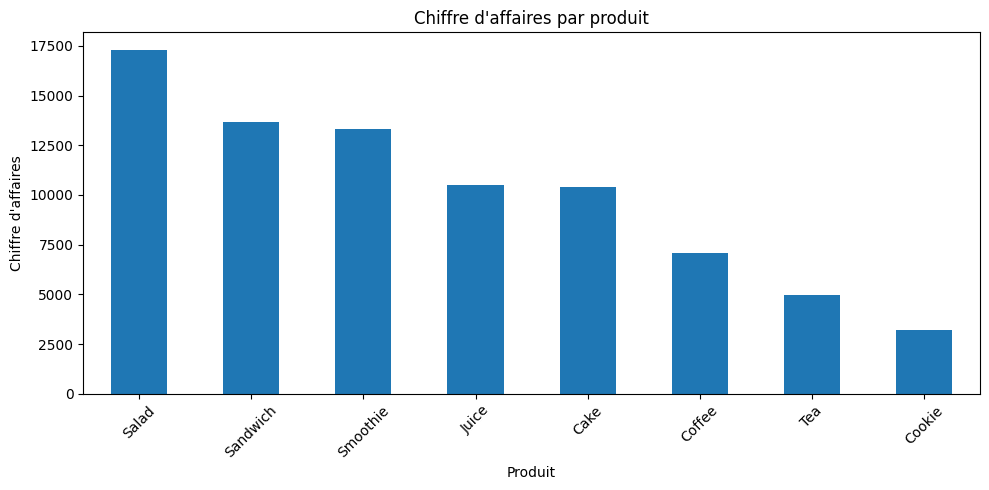

In [71]:
ca_by_item.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Chiffre d'affaires par produit")
plt.xlabel("Produit")
plt.ylabel("Chiffre d'affaires")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5.4 Volume de transactions vs chiffre d'affaires

Afin de distinguer la popularité d'un produit de sa contribution
financière, nous comparons :

- le nombre de transactions ;
- le chiffre d'affaires généré.

Cette comparaison permet d'identifier les produits dont le poids
commercial ne correspond pas nécessairement à leur fréquence d'achat.

In [72]:
product_analysis = pd.DataFrame({
    "Transactions": item_counts,
    "Chiffre_affaires": ca_by_item
})

product_analysis = product_analysis.sort_values(
    "Chiffre_affaires",
    ascending=False
)

product_analysis


,Transactions,Chiffre_affaires
Item,,
Salad,1148,17320.0
Sandwich,1131,13664.0
Smoothie,1096,13320.0
Juice,1171,10509.0
Cake,1139,10395.0
Coffee,1165,7062.0
Tea,1089,4951.5
Cookie,1092,3223.0


In [73]:
product_analysis["CA moyen par transaction"] = (
    product_analysis["Chiffre_affaires"]
    / product_analysis["Transactions"]
) 
product_analysis

,Transactions,Chiffre_affaires,CA moyen par transaction
Item,,,
Salad,1148,17320.0,15.087108
Sandwich,1131,13664.0,12.081344
Smoothie,1096,13320.0,12.153285
Juice,1171,10509.0,8.974381
Cake,1139,10395.0,9.126427
Coffee,1165,7062.0,6.061803
Tea,1089,4951.5,4.546832
Cookie,1092,3223.0,2.951465


## 5.5 Quantité totale vendue par produit

Le nombre de transactions ne correspond pas nécessairement au nombre
d'unités vendues.

Une transaction peut contenir plusieurs unités d'un même produit.

Nous calculons donc également la quantité totale vendue pour chaque
produit afin de distinguer :

- la fréquence des transactions ;
- le volume réel d'unités vendues ;
- le chiffre d'affaires généré.

In [74]:
quantity_by_item = (
    df_clean
    .dropna(subset=["Item", "Quantity"])
    .groupby("Item")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

quantity_by_item

Item
Coffee      3534.0
Juice       3505.0
Salad       3468.0
Cake        3462.0
Sandwich    3424.0
Smoothie    3330.0
Tea         3292.0
Cookie      3228.0
Name: Quantity, dtype: float64

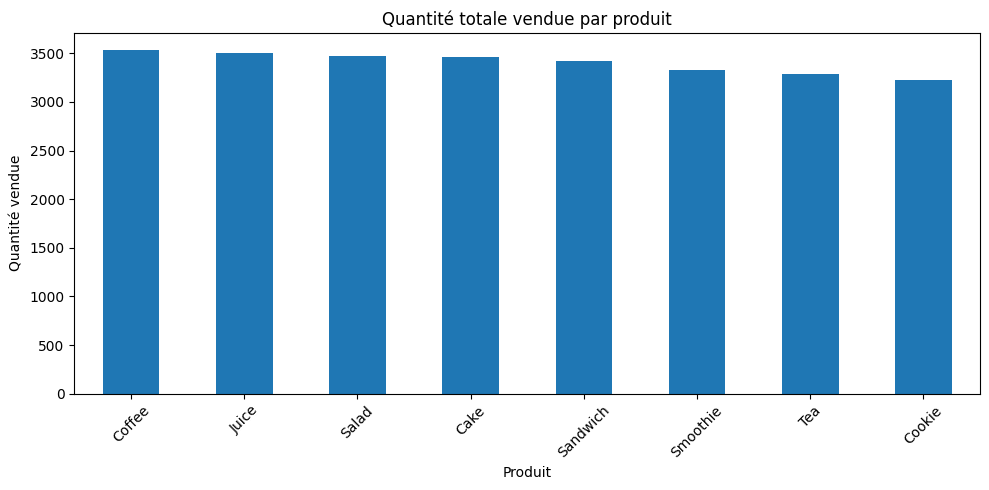

In [75]:
quantity_by_item.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Quantité totale vendue par produit")
plt.xlabel("Produit")
plt.ylabel("Quantité vendue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5.6 Quantité moyenne par transaction

Deux produits peuvent avoir un nombre similaire de transactions mais
des volumes vendus différents si les clients achètent plusieurs unités
lors d'une même transaction.

Nous calculons donc la quantité moyenne par transaction pour chaque
produit.

In [76]:
avg_quantity_by_item = (
    df_clean
    .dropna(subset=["Item", "Quantity"])
    .groupby("Item")["Quantity"]
    .mean()
    .sort_values(ascending=False)
)

avg_quantity_by_item

Item
Cake        3.050220
Smoothie    3.049451
Coffee      3.049180
Sandwich    3.040853
Tea         3.036900
Salad       3.028821
Juice       3.000856
Cookie      2.969641
Name: Quantity, dtype: float64

## 5.7 Évolution des ventes dans le temps

Les données couvrent l'année 2023. Nous allons examiner l'évolution
du chiffre d'affaires au cours des mois afin d'identifier d'éventuelles
variations saisonnières ou périodes de forte/faible activité.

Les transactions dont la date ou le montant est manquant ne peuvent
pas être utilisées pour cette analyse temporelle.

In [79]:
df_clean["Month"] = (
    df_clean["Transaction Date"]
    .dt.to_period("M")
) 
monthly_sales = (
    df_clean
    .dropna(subset=["Month", "Total Spent"])
    .groupby("Month")["Total Spent"]
    .sum()
) 
monthly_sales

Month
2023-01    7242.0
2023-02    6633.5
2023-03    7214.5
2023-04    7168.0
2023-05    6941.5
2023-06    7350.0
2023-07    6877.5
2023-08    7077.5
2023-09    6846.0
2023-10    7302.0
2023-11    6957.0
2023-12    7177.0
Freq: M, Name: Total Spent, dtype: float64

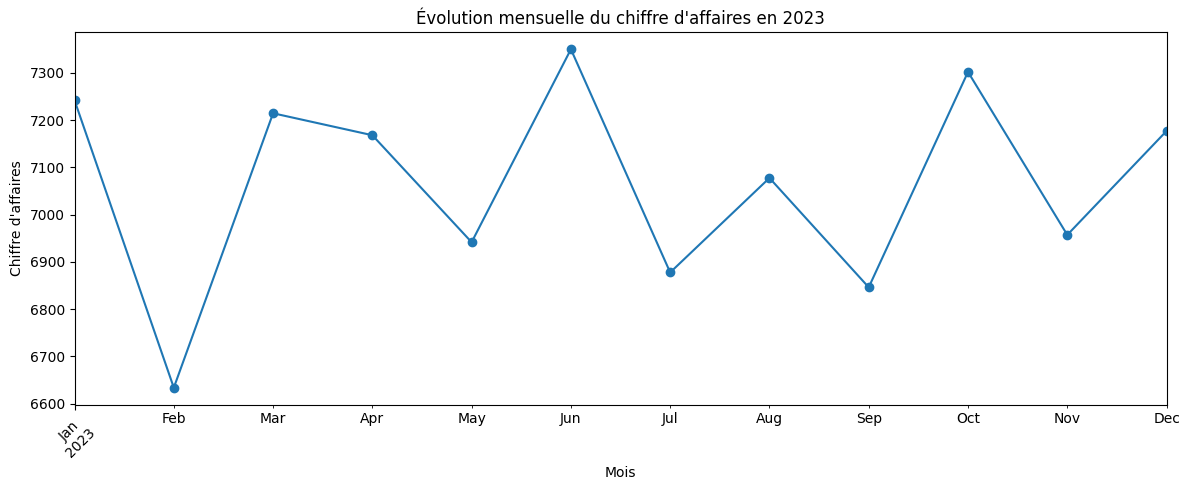

In [80]:
monthly_sales.plot(
    kind="line",
    figsize=(12, 5),
    marker="o"
)

plt.title("Évolution mensuelle du chiffre d'affaires en 2023")
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5.8 Évolution du nombre de transactions

Une variation du chiffre d'affaires peut être liée à une variation du
nombre de transactions, à une variation du montant moyen des transactions,
ou aux deux.

Nous comparons donc l'évolution du chiffre d'affaires avec le volume
de transactions afin de mieux comprendre les variations observées.

In [81]:
monthly_transactions = (
    df_clean
    .dropna(subset=["Month"])
    .groupby("Month")
    .size()
)

monthly_transactions

Month
2023-01    818
2023-02    727
2023-03    827
2023-04    774
2023-05    777
2023-06    818
2023-07    791
2023-08    803
2023-09    788
2023-10    838
2023-11    784
2023-12    795
Freq: M, dtype: int64

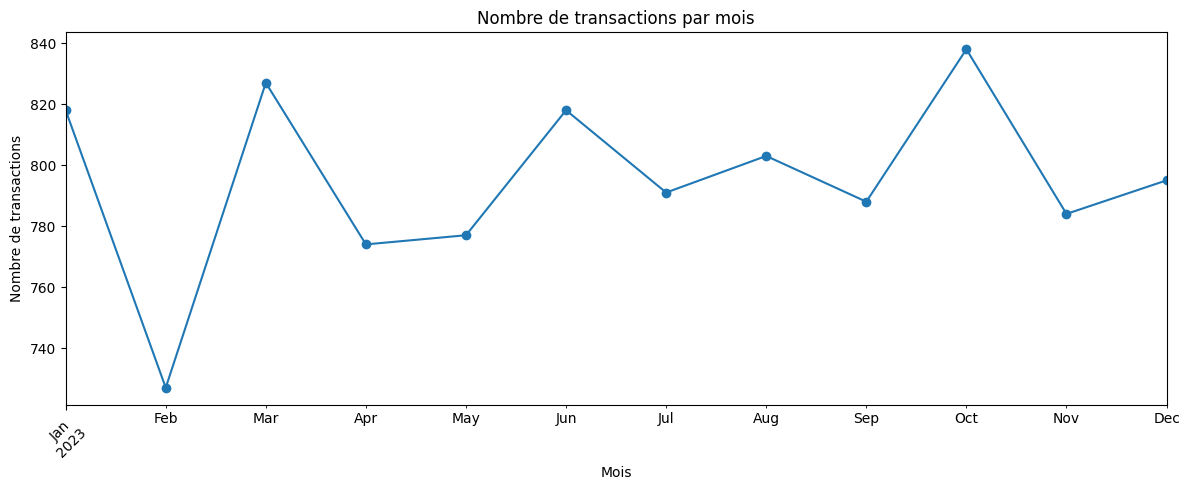

In [82]:
monthly_transactions.plot(
    kind="line",
    figsize=(12, 5),
    marker="o"
)

plt.title("Nombre de transactions par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre de transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5.9 Panier moyen mensuel

Pour comprendre les variations du chiffre d'affaires, nous calculons
également le montant moyen dépensé par transaction chaque mois.

Ainsi, une hausse du chiffre d'affaires pourra être distinguée entre :

- une hausse du nombre de transactions ;
- une augmentation du montant moyen par transaction ;
- ou une combinaison des deux.

In [83]:
monthly_avg = (
    df_clean
    .dropna(subset=["Month", "Total Spent"])
    .groupby("Month")["Total Spent"]
    .mean()
)

monthly_avg

Month
2023-01    8.896806
2023-02    9.162293
2023-03    8.744848
2023-04    9.321196
2023-05    9.003243
2023-06    9.007353
2023-07    8.716730
2023-08    8.846875
2023-09    8.732143
2023-10    8.734450
2023-11    8.896419
2023-12    9.073325
Freq: M, Name: Total Spent, dtype: float64

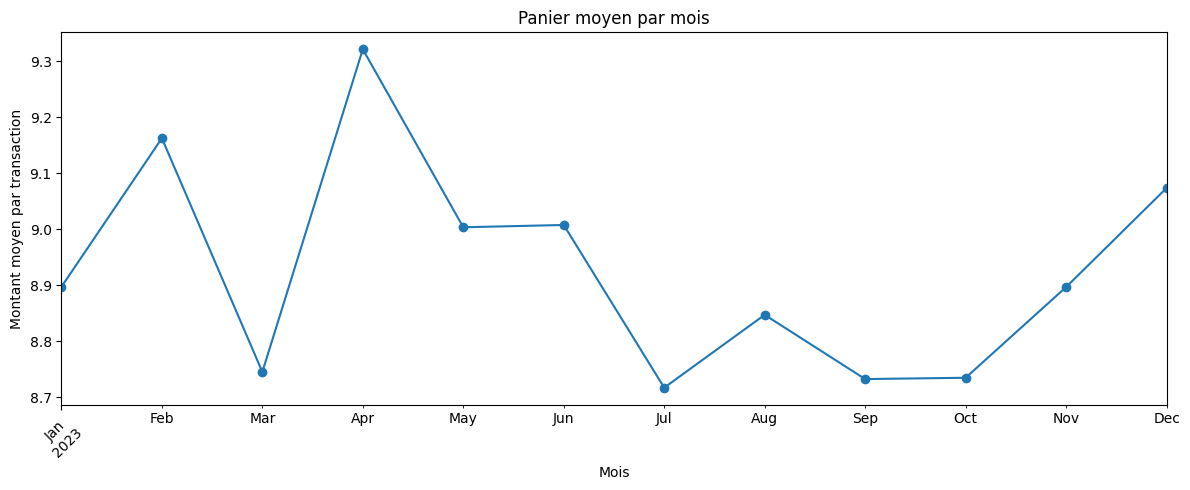

In [84]:
monthly_avg.plot(
    kind="line",
    figsize=(12, 5),
    marker="o"
)

plt.title("Panier moyen par mois")
plt.xlabel("Mois")
plt.ylabel("Montant moyen par transaction")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 6. Synthèse des principaux constats
## Insight 1 — Le produit le plus présent n'est pas celui qui génère le plus de chiffre d'affaires

Le Juice est le produit apparaissant dans le plus grand nombre de transactions (1 171 transactions), tandis que la Salad génère le chiffre d'affaires le plus élevé (17 320).

Le chiffre d'affaires moyen par transaction est également nettement supérieur pour la Salad (15,09) contre 8,97 pour le Juice.

**Constat :** la fréquence d'achat d'un produit ne correspond pas nécessairement à sa contribution au chiffre d'affaires.

## Insight 2 — Le nombre de transactions ne suffit pas à expliquer le chiffre d'affaires mensuel

Octobre compte le plus grand nombre de transactions (838), mais ne réalise pas le chiffre d'affaires mensuel le plus élevé (7 302).

À l'inverse, juin génère le chiffre d'affaires mensuel maximal (7 350) avec seulement 818 transactions.

**Constat :** le volume de transactions n'est pas le seul facteur déterminant du chiffre d'affaires ; le montant généré par transaction intervient également.

## Insight 3 — Les quantités moyennes achetées sont très similaires selon les produits

La quantité moyenne par transaction est comprise entre 2,97 et 3,05 unités selon les produits.

Malgré cette faible variation des quantités, le chiffre d'affaires moyen par transaction varie fortement, de 2,95 pour Cookie à 15,09 pour Salad.

**Constat :** les écarts de chiffre d'affaires entre produits ne semblent pas principalement liés à la quantité moyenne achetée.

# 7. Journal de curiosité
a- **Pourquoi le chiffre d'affaires de certains produits est-il beaucoup plus élevé malgré des quantités moyennes par transaction très proches ?**
→ Il faudrait analyser les prix unitaires moyens et leur évolution pour comprendre leur influence.

b- **Pourquoi le Juice est-il le produit le plus présent dans les transactions alors que la Salad génère davantage de chiffre d'affaires ?**
→ Il serait utile d'étudier la composition des paniers, les prix et les éventuelles promotions.

c- **Pourquoi les informations de localisation et de mode de paiement sont-elles aussi souvent absentes ?**
→ Il faudrait interroger la source des données pour savoir si ces champs étaient facultatifs ou si les informations ont été perdues lors de la collecte.